downloading NLTK - Natural Language Toolkit, python library to process human language data. 

In [3]:
!pip install textstat
import nltk
nltk.download('punkt') #tokenizer
nltk.download('wordnet') #for lemmatization
nltk.download('vader_lexicon') #sentiment analysis
nltk.download('stopwords') #for text processing
nltk.download('averaged_perceptron_tagger') #part of speech tagging
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/chehakarora/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/chehakarora/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/chehakarora/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chehakarora/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/chehakarora/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/chehakarora/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng 

True

importing NLP, Machine learning and clustering libraries 

In [57]:
import re
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from textstat import flesch_reading_ease, gunning_fog
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sentence_transformers import SentenceTransformer
import umap
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc, silhouette_score
!pip install textstat gensim sentence-transformers umap-learn hdbscan
from sklearn.cluster import DBSCAN
import hdbscan
import plotly.express as px
from scipy.sparse import hstack
from sklearn.manifold import TSNE


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [8]:
# Load datasets
data_train = pd.read_csv('trainSA.csv')
data_test = pd.read_csv('testSA.csv')

# Display basic info
print("Dataset Overview:")
print(data_train.head())


Dataset Overview:
                                                text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival


In [10]:
#Text Preprocessing
def preprocess_text(text):
    if isinstance(text, str):
        # Convert to lowercase and remove leading/trailing spaces
        text = text.lower().strip()
        # Remove special characters
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        # Tokenize
        tokens = word_tokenize(text)
        # Lemmatize
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words]
        return ' '.join(tokens)
    return ""
    
# Apply preprocessing to training and test data

data_train['clean_text'] = data_train['text'].apply(preprocess_text)
data_test['clean_text'] = data_test['text'].apply(preprocess_text)


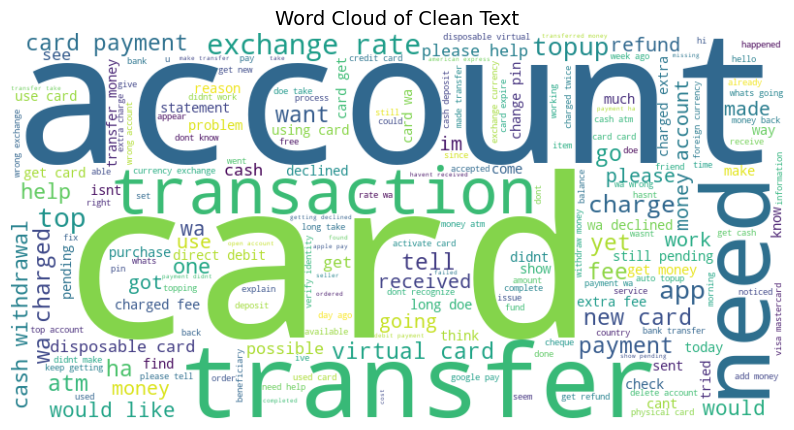

In [140]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_corpus = " ".join(data_train['clean_text'].dropna())

wordcloud = WordCloud(
    width=800, height=400, 
    background_color='white', 
    colormap='viridis', 
    stopwords='english', 
    max_words=200
).generate(text_corpus)


plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.title("Word Cloud of Clean Text", fontsize=14)
plt.show()



BERT - Bidirectional Encoder Representations from Transformers converts into numerical embeddings. better than Word2vec because it captures the sentence level meaning. 

In [23]:
#BERT Model
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
train_embeddings = bert_model.encode(data_train['clean_text'])
test_embeddings = bert_model.encode(data_test['clean_text'])



VADER is optimized for social media & short text and doesn't need labeled data.

In [26]:
sia = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    scores = sia.polarity_scores(text)
    return pd.Series(scores)

sentiment_train = data_train['clean_text'].apply(get_sentiment_scores)
sentiment_test = data_test['clean_text'].apply(get_sentiment_scores)
print(sentiment_train.head()) 
print(sentiment_test.head())   



     neg    neu  pos  compound
0  0.000  1.000  0.0    0.0000
1  0.000  1.000  0.0    0.0000
2  0.000  1.000  0.0    0.0000
3  0.000  1.000  0.0    0.0000
4  0.434  0.566  0.0   -0.3182
   neg    neu    pos  compound
0  0.0  1.000  0.000    0.0000
1  0.0  1.000  0.000    0.0000
2  0.0  0.288  0.712    0.7506
3  0.0  1.000  0.000    0.0000
4  0.0  0.556  0.444    0.3400


TFIDF - Term Frequency - Inverse Document Frequency converts cleaned text into numerical features for machine learning models.
BERT embeddings capture semantic meaning but can be too dense for certain models.
TF-IDF is more interpretable and works well with classic ML algorithms.
Together, they give complementary insights into the text

In [28]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=40000,  
    ngram_range=(1, 5),  
    stop_words='english',
    min_df=2,
    max_df=0.95,
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True 
)

text_features_train = tfidf.fit_transform(data_train['clean_text']).toarray()
text_features_test = tfidf.transform(data_test['clean_text']).toarray()




In [69]:
#Text Complexity & Readability Features
import textstat

def extract_readability_features(text):
    return pd.Series({
        'flesch_reading_ease': textstat.flesch_reading_ease(text),
        'gunning_fog': textstat.gunning_fog(text),
        'smog_index': textstat.smog_index(text),
        'automated_readability': textstat.automated_readability_index(text),
    })


readability_train = data_train['clean_text'].apply(extract_readability_features)
readability_test = data_test['clean_text'].apply(extract_readability_features)

In [71]:
#Lexical Diversity Features
def lexical_diversity(text):
    words = word_tokenize(text)
    unique_words = set(words)
    return len(unique_words) / len(words) if words else 0

data_train['lexical_diversity'] = data_train['clean_text'].apply(lexical_diversity)
data_test['lexical_diversity'] = data_test['clean_text'].apply(lexical_diversity)


In [ ]:
#Sentiment Intensity (Polarity & Subjectivity)
sia = SentimentIntensityAnalyzer()

def extract_sentiment_features(text):
    scores = sia.polarity_scores(text)
    return pd.Series({
        'sentiment_pos': scores['pos'],
        'sentiment_neg': scores['neg'],
        'sentiment_neu': scores['neu'],
        'sentiment_compound': scores['compound']
    })

# Apply to datasets
sentiment_train = data_train['clean_text'].apply(extract_sentiment_features)
sentiment_test = data_test['clean_text'].apply(extract_sentiment_features)

In [75]:
#Structural Features (Sentence & Word Counts)
def structural_features(text):
    return pd.Series({
        'word_count': len(word_tokenize(text)),
        'sentence_count': len(sent_tokenize(text)),
        'avg_word_length': np.mean([len(word) for word in word_tokenize(text)]) if text else 0
    })

structural_train = data_train['clean_text'].apply(structural_features)
structural_test = data_test['clean_text'].apply(structural_features)


In [89]:
# Convert embeddings and TF-IDF features to DataFrame
train_embeddings_df = pd.DataFrame(train_embeddings, index=data_train.index)
test_embeddings_df = pd.DataFrame(test_embeddings, index=data_test.index)

text_features_train_df = pd.DataFrame(text_features_train, index=data_train.index)
text_features_test_df = pd.DataFrame(text_features_test, index=data_test.index)

# Merge all features into a single DataFrame
train_features = pd.concat([
    readability_train,
    sentiment_train,
    structural_train,
    text_features_train_df,  # Converted to DataFrame
    data_train[['lexical_diversity']]
], axis=1)

test_features = pd.concat([
    readability_test,
    sentiment_test,
    structural_test,
    text_features_test_df,  # Converted to DataFrame
    data_test[['lexical_diversity']]
], axis=1)


# all column names are strings
train_features.columns = train_features.columns.astype(str)
test_features.columns = test_features.columns.astype(str)

# scaling
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

# scaled features back to DataFrame with string column names
train_features_scaled_df = pd.DataFrame(train_features_scaled, columns=train_features.columns, index=data_train.index)
test_features_scaled_df = pd.DataFrame(test_features_scaled, columns=test_features.columns, index=data_test.index)

# Concatenate scaled features with embeddings
final_train_features = pd.concat([train_features_scaled_df, train_embeddings_df], axis=1)
final_test_features = pd.concat([test_features_scaled_df, test_embeddings_df], axis=1)

# final shape
print(final_train_features.shape, final_test_features.shape)


(10003, 10815) (3080, 10815)


Trying UMAP first 

In [91]:
#dimensionality reduction
reducer = umap.UMAP(n_components=3, n_neighbors=10, min_dist=0.1, metric='cosine')
train_umap = reducer.fit_transform(final_train_features)
test_umap = reducer.transform(final_test_features)

contamination: Expected proportion of anomalies in the dataset.
n_estimators: Number of trees in the forest. Higher values = More stable anomaly detection.
max_samples: Number of samples per tree. Lower values = Faster but less accurate.


In [93]:
#isolation forest
iso_forest = IsolationForest(contamination=0.1, n_estimators=300, max_samples="auto", random_state=42)
anomaly_labels = iso_forest.fit_predict(train_umap)

# Convert anomaly labels: 1 (normal), -1 (anomaly)
data_train['anomaly'] = anomaly_labels
data_train['anomaly'] = data_train['anomaly'].map({1: 'Normal', -1: 'Anomaly'})







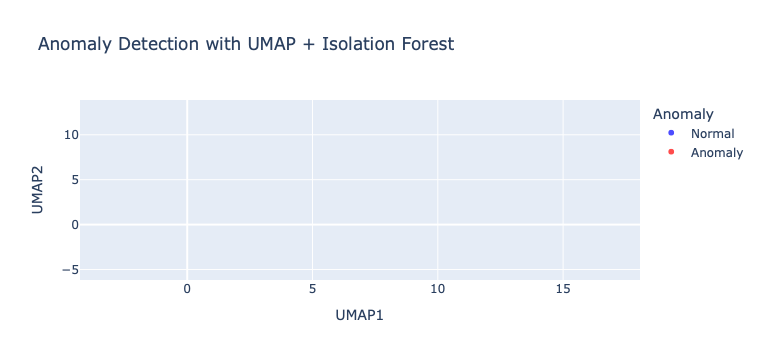

In [95]:
umap_df = pd.DataFrame(train_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
umap_df['Anomaly'] = data_train['anomaly']
umap_df['Text'] = data_train['text']  

# 2D Scatter Plot 
fig = px.scatter(
    umap_df, x='UMAP1', y='UMAP2', color='Anomaly',
    title="Anomaly Detection with UMAP + Isolation Forest",
    color_discrete_map={'Normal': 'blue', 'Anomaly': 'red'},
    hover_data=['Text'],  
    opacity=0.7
)
fig.show()

HDBSCAN: Hierarchical Density-Based Spatial Clustering of Applications with Noise 
builds a hierarchical clustering tree of the data.
Collapses the tree into the most stable clusters.
Points not belonging to any cluster are labeled as anomalies 
Isolation Forest randomly splits the data using decision trees.Anomalies are "isolated" faster than normal points.Works well for high-dimensional data but assumes anomalies are far from normal points. 


In [97]:
#HDBSCAN

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,  
    min_samples=10,       
    cluster_selection_method='eom'  
)

# Fit to reduced embeddings
hdbscan_labels = clusterer.fit_predict(train_umap)

# Mark anomalies (-1) in the dataset
data_train['anomaly'] = np.where(hdbscan_labels == -1, 'Anomaly', 'Normal')

trying TSNE

In [104]:
# Reduce high-dimensional data to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
train_tsne = tsne.fit_transform(train_umap)


tsne_df = pd.DataFrame(train_tsne, columns=['x', 'y'])
tsne_df['anomaly'] = data_train['anomaly']
tsne_df['text'] = data_train['text']  


tsne_df.head()


,x,y,anomaly,text
0,25.318708,3.343465,Anomaly,I am still waiting on my card?
1,-8.080404,-92.985847,Normal,What can I do if my card still hasn't arrived ...
2,23.691908,1.491835,Anomaly,I have been waiting over a week. Is the card s...
3,80.345604,-3.137183,Normal,Can I track my card while it is in the process...
4,40.764015,-27.080996,Normal,"How do I know if I will get my card, or if it ..."


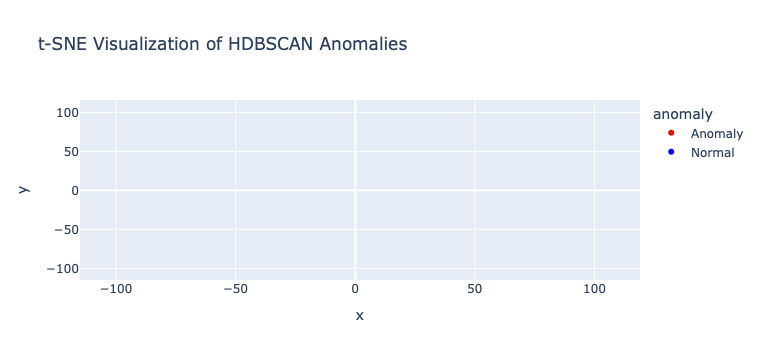

In [105]:
fig = px.scatter(
    tsne_df, 
    x='x', y='y', 
    color='anomaly',  
    hover_data=['text'], 
    title="t-SNE Visualization of HDBSCAN Anomalies",
    color_discrete_map={'Anomaly': 'red', 'Normal': 'blue'} 
)

fig.show()

In [106]:
# Silhouette score for UMAP-reduced data
umap_silhouette = silhouette_score(train_umap, hdbscan_labels)

print(f"Silhouette Score for UMAP: {umap_silhouette:.4f}")


Silhouette Score for UMAP: 0.1944


In [107]:
# Silhouette score for t-SNE reduced data
tsne_silhouette = silhouette_score(train_tsne, hdbscan_labels)

print(f"Silhouette Score for t-SNE: {tsne_silhouette:.4f}")


Silhouette Score for t-SNE: 0.2341


In [116]:
print(anomalies_df.columns)


Index(['neg', 'neu', 'pos', 'compound'], dtype='object')


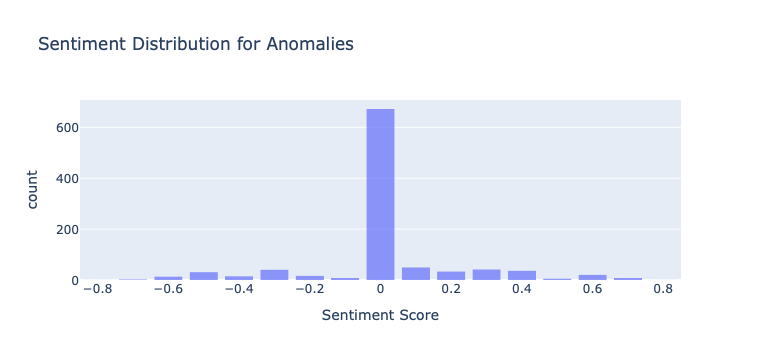

In [120]:
fig = px.histogram(
    anomalies_df, 
    x="compound",  # Change to "pos", "neg", or "neu" if needed
    nbins=30, 
    title="Sentiment Distribution for Anomalies",
    labels={"compound": "Sentiment Score"},
    opacity=0.7
)

fig.update_layout(bargap=0.2, hovermode="x")


fig.show()

In [134]:
print("Cluster distribution:\n", pd.Series(anomaly_labels).value_counts())


Cluster distribution:
  1    9002
-1    1001
Name: count, dtype: int64


In [136]:
cluster_analysis = anomalies_df.groupby('cluster').agg({
    'compound': 'mean'
}).rename(columns={'compound': 'avg_sentiment'})

cluster_analysis['anomaly_count'] = anomalies_df['cluster'].value_counts()
cluster_analysis = cluster_analysis.sort_values(by='anomaly_count', ascending=False)

print("Final Anomaly Distribution by Cluster:")
print(cluster_analysis)





Final Anomaly Distribution by Cluster:
         avg_sentiment  anomaly_count
cluster                              
-1            0.012575           1001


word frequency in anomalies- this might help in identifying patterns in anomalous texts.
For example: If "fraud" or "error" appears often, anomalies may be negative or technical issues.

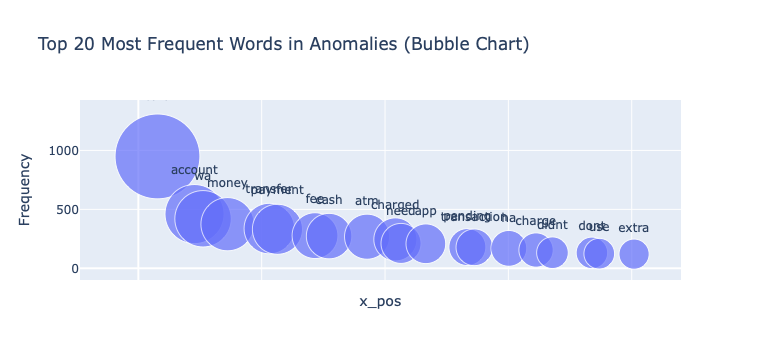

In [156]:
from sklearn.feature_extraction.text import CountVectorizer


anomalies_text = data_train[data_train['anomaly'] == 'Anomaly']['clean_text'].dropna()


vectorizer = CountVectorizer(stop_words='english')
word_counts = vectorizer.fit_transform(anomalies_text)


word_freq = dict(zip(vectorizer.get_feature_names_out(), word_counts.sum(axis=0).tolist()[0]))
word_freq_df = pd.DataFrame(word_freq.items(), columns=['word', 'count'])


word_freq_df = word_freq_df.sort_values(by='count', ascending=False).head(20)


word_freq_df['x_pos'] = np.linspace(1, len(word_freq_df), len(word_freq_df))  # Spread evenly
word_freq_df['x_pos'] += np.random.uniform(-0.5, 0.5, len(word_freq_df))  # Add jitter


fig = px.scatter(word_freq_df, 
                 x='x_pos',  # Jittered x-axis
                 y='count',  
                 size='count',  
                 text='word',  
                 title="Top 20 Most Frequent Words in Anomalies (Bubble Chart)",  
                 labels={'count': 'Frequency', 'word': 'Word'},  
                 hover_name='word',  
                 size_max=60)  # Adjust bubble size

fig.update_traces(textposition='top center')

# Hide X-axis labels (since it's just for spacing)
fig.update_layout(xaxis=dict(showticklabels=False))

# Show plot
fig.show()




KMEANs

In [182]:
from sklearn.cluster import KMeans
import pandas as pd


iso_forest = IsolationForest(contamination=0.1, n_estimators=300, max_samples="auto", random_state=42)
anomaly_labels = iso_forest.fit_predict(train_features_scaled)


data_train['anomaly'] = anomaly_labels
data_train['anomaly'] = data_train['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Apply K-Means clustering
num_clusters = 2  #Normal vs. Anomaly
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(train_features_scaled)

# Map clusters based on anomaly distribution
data_train['kmeans_cluster'] = train_clusters

# Analyze how K-Means clusters match anomalies
cluster_analysis = data_train.groupby('kmeans_cluster')['anomaly'].value_counts().unstack()
print("\nCluster vs. Anomaly Distribution:\n", cluster_analysis)


# Identify which cluster has more anomalies
anomaly_cluster = cluster_analysis.idxmax(axis=0)['Anomaly']
data_train['kmeans_cluster'] = data_train['kmeans_cluster'].apply(lambda x: 'Anomaly' if x == anomaly_cluster else 'Normal')

# Final check
print("\nFinal Cluster Labels:\n", data_train['kmeans_cluster'].value_counts())




Cluster vs. Anomaly Distribution:
 anomaly         Anomaly  Normal
kmeans_cluster                 
0                 999.0  9002.0
1                   2.0     NaN

Final Cluster Labels:
 kmeans_cluster
Anomaly    10001
Normal         2
Name: count, dtype: int64


Local Outlier Factor is another anomaly detection technique that identifies outliers based on local density deviations. When anomalies are not isolated but exist in structured data.
When anomalies look similar to normal points but have a subtle density difference.

In [190]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=False)
lof_labels = lof.fit_predict(train_features_scaled)


# Add results to DataFrame
data_train['lof_anomaly'] = lof_labels
data_train['lof_anomaly'] = data_train['lof_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Check distribution
print(data_train['lof_anomaly'].value_counts())


lof_anomaly
Normal     9502
Anomaly     501
Name: count, dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



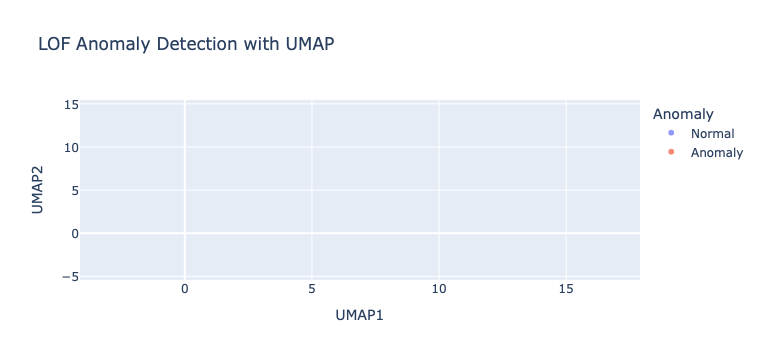

In [192]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
train_umap_2d = umap_reducer.fit_transform(train_features_scaled)


umap_df = pd.DataFrame(train_umap_2d, columns=['UMAP1', 'UMAP2'])
umap_df['Anomaly'] = data_train['lof_anomaly']
umap_df['Text'] = data_train['text']  # Add original text for hover tool


fig = px.scatter(
    umap_df, x='UMAP1', y='UMAP2', 
    color='Anomaly', 
    hover_data=['Text'],  # Show text on hover
    title="LOF Anomaly Detection with UMAP",
    opacity=0.7
)

fig.show()


In [193]:

numeric_labels = np.where(data_train['lof_anomaly'] == 'Anomaly', 0, 1)  # 0 for anomalies, 1 for normal


sil_score = silhouette_score(train_umap_2d, numeric_labels)

print(f"Silhouette Score for LOF Anomaly Detection: {sil_score:.4f}")


Silhouette Score for LOF Anomaly Detection: -0.1211


In [196]:
from transformers import pipeline

# Load emotion classification pipeline
emotion_classifier = pipeline("text-classification", model="joeddav/distilbert-base-uncased-go-emotions-student")

# Apply emotion classification to text
def get_emotion(text):
    result = emotion_classifier(text)[0]
    return result['label']

# Add emotion column to your DataFrame
data_test['emotion'] = data_test['clean_text'].apply(get_emotion)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Device set to use mps:0


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Device set to use mps:0
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



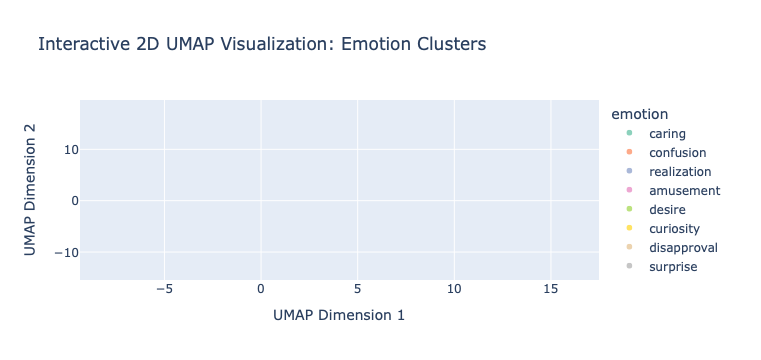

In [200]:
from transformers import pipeline
from transformers import pipeline
import umap
import plotly.express as px
import pandas as pd

# Load emotion classification pipeline
emotion_classifier = pipeline("text-classification", model="joeddav/distilbert-base-uncased-go-emotions-student")

# Function to classify emotion
def get_emotion(text):
    result = emotion_classifier(text)[0]
    return result['label']

# Apply emotion classification to test set
data_test['emotion'] = data_test['clean_text'].apply(get_emotion)

# Apply UMAP to reduce embeddings to 2D
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
test_umap_2d = umap_reducer.fit_transform(test_embeddings)  # Ensure 'test_embeddings' exists

# Convert to DataFrame
umap_df = pd.DataFrame(test_umap_2d, columns=['UMAP1', 'UMAP2'])
umap_df['emotion'] = data_test['emotion']
umap_df['text'] = data_test['clean_text']  # Keep text for hover info

# Create interactive scatterplot with Plotly
fig = px.scatter(
    umap_df, x='UMAP1', y='UMAP2', 
    color='emotion', 
    hover_data=['text'], 
    title='Interactive 2D UMAP Visualization: Emotion Clusters',
    color_discrete_sequence=px.colors.qualitative.Set2  # Softer color palette
)

# Improve marker visibility
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(
    xaxis=dict(title='UMAP Dimension 1', showgrid=True, zeroline=False),
    yaxis=dict(title='UMAP Dimension 2', showgrid=True, zeroline=False),
    hovermode='closest',  # Show hover info for the nearest point
    dragmode='zoom'  # Enable zoom
)

# Show plot
fig.show()


/var/folders/33/lqn7phm924b50fc5q7jd2b7h0000gn/T/ipykernel_10510/1979468778.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




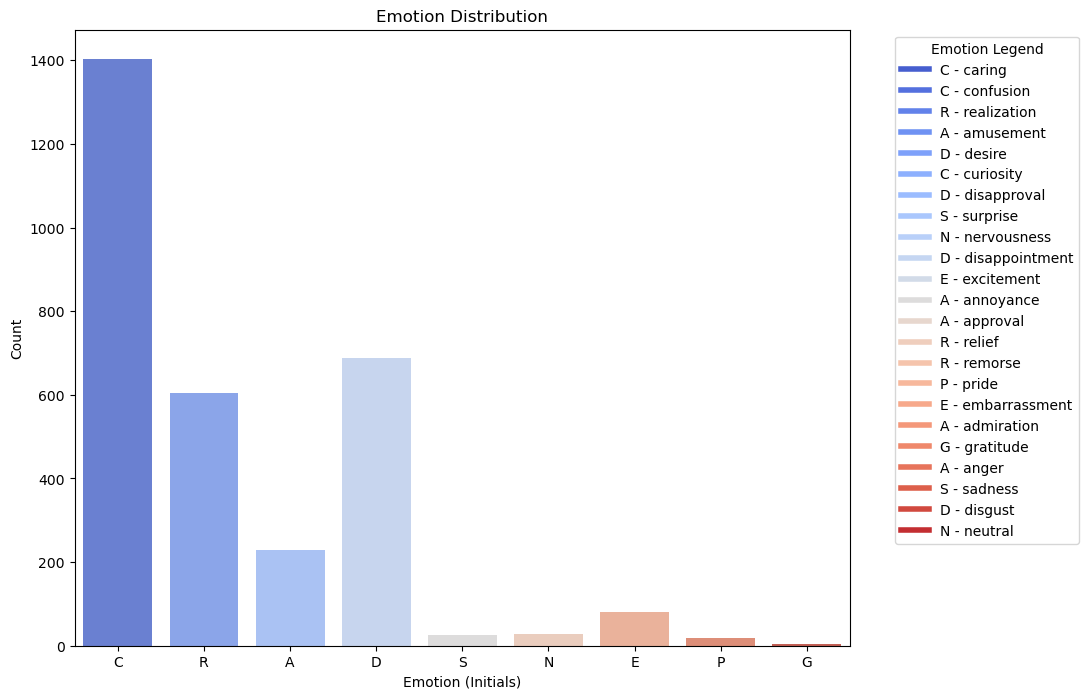

In [204]:

emotion_mapping = {emotion: emotion[0].upper() for emotion in data_test['emotion'].unique()}


data_test['emotion_initial'] = data_test['emotion'].map(emotion_mapping)


plt.figure(figsize=(10, 8))
ax = sns.countplot(data=data_test, x='emotion_initial', palette='coolwarm')

plt.title("Emotion Distribution")
plt.xlabel("Emotion (Initials)")
plt.ylabel("Count")


legend_labels = [plt.Line2D([0], [0], color=sns.color_palette('coolwarm', len(emotion_mapping))[i], lw=4, label=f"{initial} - {full_name}") 
                 for i, (full_name, initial) in enumerate(emotion_mapping.items())]

plt.legend(handles=legend_labels, title="Emotion Legend", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


In [222]:
!pip install wordcloud

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
